# SHAP Interpretation - Preferred Credit-Risk Model

Interprets the selected model `xgb_neutral_09_without_grade_subgrade_with_int_rate` using SHAP.

Follows the plan in `Interpretation_SHAP/README.md`:
1. Load the selected XGBoost model and the feature matrix it was trained on.
2. Run SHAP on a manageable validation sample (with a test-set stability check).
3. Global outputs: mean-abs importance table, summary plot, top positive risk drivers, dependence plots.
4. Local outputs: high-risk and contrasting low-risk accepted-loan examples.
5. Draft reason-code mapping, aggregated to reason-code families.

**Boundary:** SHAP here is a technical explanation of model behavior, not a legal adverse-action explanation.

In [1]:
from __future__ import annotations

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

RANDOM_STATE = 42
SHAP_SAMPLE_ROWS = 5000  # sample for SHAP; full sets are too large for TreeExplainer plots
N_LOCAL_EXAMPLES = 75     # number of high-risk accepted loans to explain individually
N_DEPENDENCE = 6         # number of top continuous features to draw dependence plots for
TOP_K = 15               # top features to report in global / local tables

print('shap version:', shap.__version__)

shap version: 0.51.0


In [2]:
# Resolve project root (works regardless of where the kernel launches)
current = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [current, *current.parents]:
    if candidate.name == 'CreditRiskRAG':
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate CreditRiskRAG project root from ' + str(current))

DATASET_DIR = PROJECT_ROOT / 'Modeling' / 'Preprocessing' / 'preprocessing_outputs' / 'datasets'
MODEL_DIR = PROJECT_ROOT / 'Modeling' / 'modeling_outputs' / 'xgboost_grade_int_rate_ablation' / 'models'
OUT_DIR = PROJECT_ROOT / 'Interpretation_SHAP' / 'shap_outputs'
TABLE_DIR = OUT_DIR / 'tables'
PLOT_DIR = OUT_DIR / 'plots'
REASON_DIR = PROJECT_ROOT / 'Interpretation_SHAP' / 'reason_codes'
for d in [TABLE_DIR, PLOT_DIR, REASON_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Model dir:', MODEL_DIR)

Project root: /Volumes/Yash's Extreme SSD/ML Project/Final/CreditRiskRAG
Model dir: /Volumes/Yash's Extreme SSD/ML Project/Final/CreditRiskRAG/Modeling/modeling_outputs/xgboost_grade_int_rate_ablation/models


In [3]:
# Load the preferred selected model. Prefer the documented name; fall back to any *_selected_model.joblib.
PREFERRED = 'xgb_neutral_09_without_grade_subgrade_with_int_rate_selected_model.joblib'
model_path = MODEL_DIR / PREFERRED
if not model_path.exists():
    candidates = sorted(MODEL_DIR.glob('*_selected_model.joblib'))
    if not candidates:
        raise FileNotFoundError(
            f'No selected model found in {MODEL_DIR}. Run scripts/test_xgboost_grade_int_rate_combinations.py first.'
        )
    model_path = candidates[0]
    print('Preferred name not found; using:', model_path.name)

model = joblib.load(model_path)
print('Loaded model:', model_path.name)

if hasattr(model, 'feature_names_in_'):
    MODEL_FEATURES = list(model.feature_names_in_)
else:
    MODEL_FEATURES = list(model.get_booster().feature_names)
print('Model feature count:', len(MODEL_FEATURES))

Loaded model: xgb_neutral_09_without_grade_subgrade_with_int_rate_selected_model.joblib
Model feature count: 60


In [4]:
# Load feature matrices and align columns to the model's expected features.
# Model was trained on the missingness_challenger set with grade/sub_grade dropped, int_rate kept.
def load_X(split: str) -> pd.DataFrame:
    X = pd.read_parquet(DATASET_DIR / f'missingness_challenger_{split}_X.parquet')
    missing = [c for c in MODEL_FEATURES if c not in X.columns]
    if missing:
        raise KeyError(f'Model features missing from {split} matrix: {missing[:10]}')
    return X[MODEL_FEATURES]

def load_y(split: str) -> pd.Series:
    return pd.read_parquet(DATASET_DIR / f'{split}_y.parquet')['target_bad'].astype(int)

X_validation, X_test = load_X('validation'), load_X('test')
y_validation, y_test = load_y('validation'), load_y('test')
print('validation X:', X_validation.shape, '| test X:', X_test.shape)

validation X: (186920, 60) | test X: (195749, 60)


In [5]:
# Reproducible SHAP samples for validation (primary) and test (stability check).
def shap_sample(X: pd.DataFrame) -> pd.DataFrame:
    return X.sample(n=min(SHAP_SAMPLE_ROWS, len(X)), random_state=RANDOM_STATE)

X_val_s = shap_sample(X_validation)
y_val_s = y_validation.loc[X_val_s.index]
X_test_s = shap_sample(X_test)

explainer = shap.TreeExplainer(model)
expl_val = explainer(X_val_s)   # Explanation: .values (n, features), .base_values
expl_test = explainer(X_test_s)
shap_val = expl_val.values
print('validation SHAP:', shap_val.shape, '| test SHAP:', expl_test.values.shape)

validation SHAP: (5000, 60) | test SHAP: (5000, 60)


## Global interpretation (validation)

In [6]:
# Mean absolute SHAP importance (global ranking of which features drive risk).
importance = (
    pd.DataFrame({
        'feature': X_val_s.columns,
        'mean_abs_shap': np.abs(shap_val).mean(axis=0),
        'mean_signed_shap': shap_val.mean(axis=0),  # >0 => on average pushes toward higher default risk
    })
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)
importance.to_csv(TABLE_DIR / 'shap_global_mean_abs_importance.csv', index=False)
importance.head(TOP_K)

,feature,mean_abs_shap,mean_signed_shap
0,int_rate_clean,0.392764,-0.034728
1,term_months,0.245731,-0.063596
2,acc_open_past_24mths,0.164227,0.006757
3,dti,0.115910,-0.013005
4,fico_mean,0.097573,-0.010771
5,annual_inc,0.082181,-0.017044
6,loan_amnt,0.078875,-0.017901
7,avg_cur_bal,0.065407,-0.005476
8,mort_acc,0.046492,0.001692
9,total_acc,0.043176,0.003996


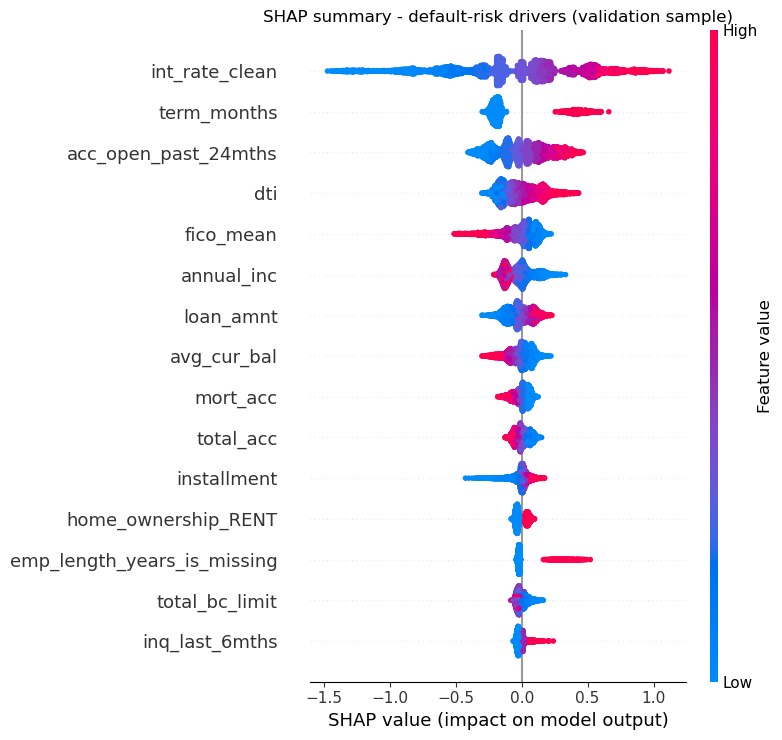

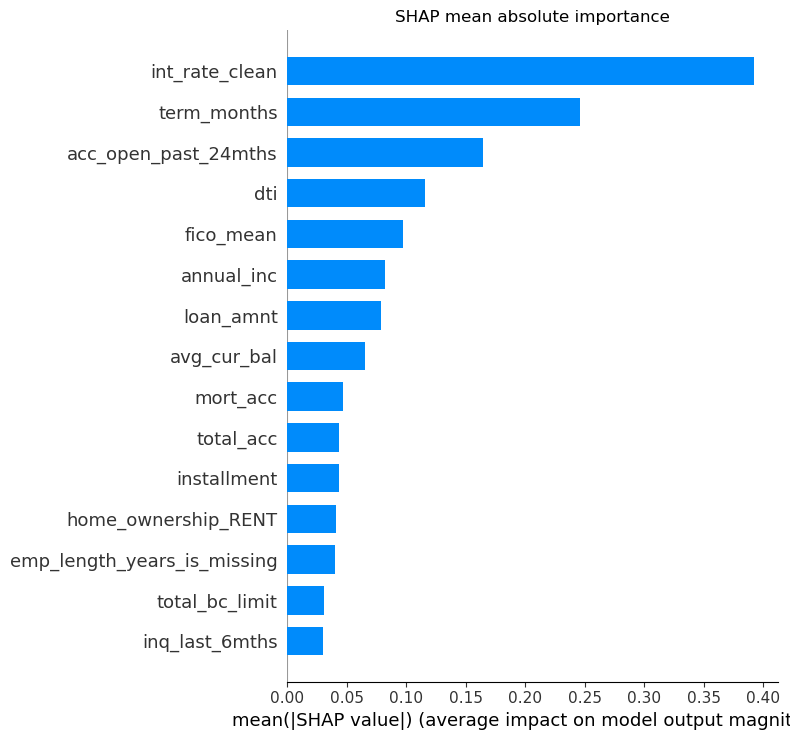

In [7]:
# SHAP summary (beeswarm) and mean|SHAP| bar plots.
plt.figure()
shap.summary_plot(shap_val, X_val_s, max_display=TOP_K, show=False)
plt.title('SHAP summary - default-risk drivers (validation sample)')
plt.tight_layout(); plt.savefig(PLOT_DIR / 'shap_summary_beeswarm.png', dpi=150, bbox_inches='tight'); plt.show()

plt.figure()
shap.summary_plot(shap_val, X_val_s, plot_type='bar', max_display=TOP_K, show=False)
plt.title('SHAP mean absolute importance')
plt.tight_layout(); plt.savefig(PLOT_DIR / 'shap_mean_abs_bar.png', dpi=150, bbox_inches='tight'); plt.show()

In [8]:
# Top features that, on average, push predictions toward higher default risk.
top_positive = (
    importance[importance['mean_signed_shap'] > 0]
    .sort_values('mean_signed_shap', ascending=False)
    .head(TOP_K).reset_index(drop=True)
)
top_positive.to_csv(TABLE_DIR / 'shap_top_positive_risk_drivers.csv', index=False)
top_positive

,feature,mean_abs_shap,mean_signed_shap
0,revol_bal,0.026601,0.007461
1,acc_open_past_24mths,0.164227,0.006757
2,total_acc,0.043176,0.003996
3,credit_history_years,0.015606,0.003246
4,verification_status_Source Verified,0.023624,0.002491
5,verification_status_Verified,0.011838,0.002474
6,bc_util,0.018897,0.002246
7,verification_status_Not Verified,0.009532,0.001950
8,mort_acc,0.046492,0.001692
9,mths_since_last_record,0.007819,0.001492


Dependence plots for: ['int_rate_clean', 'term_months', 'acc_open_past_24mths', 'dti', 'fico_mean', 'annual_inc']


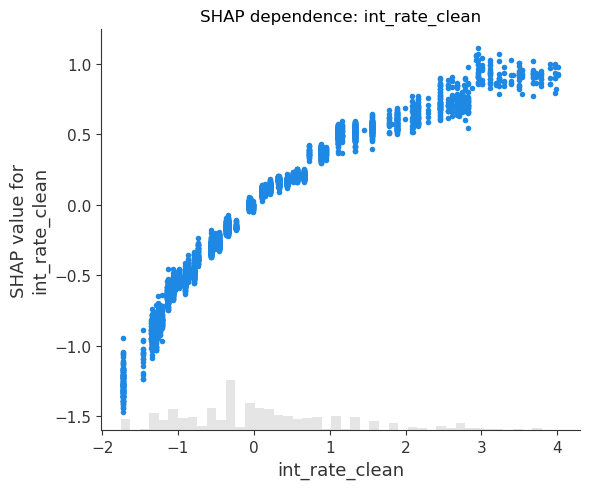

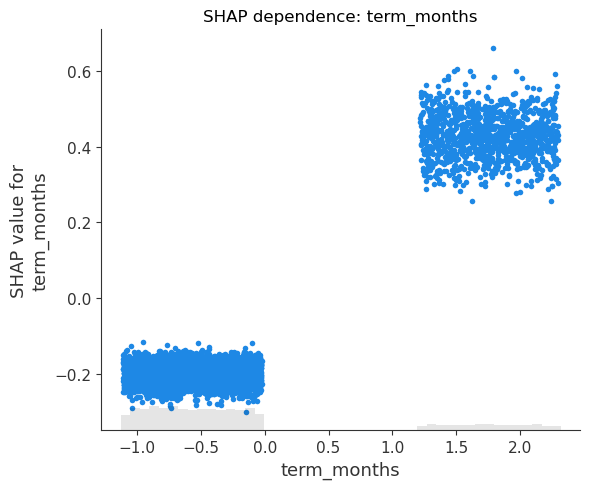

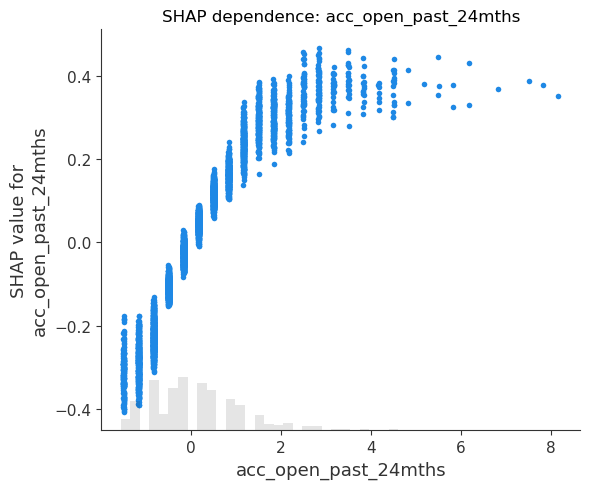

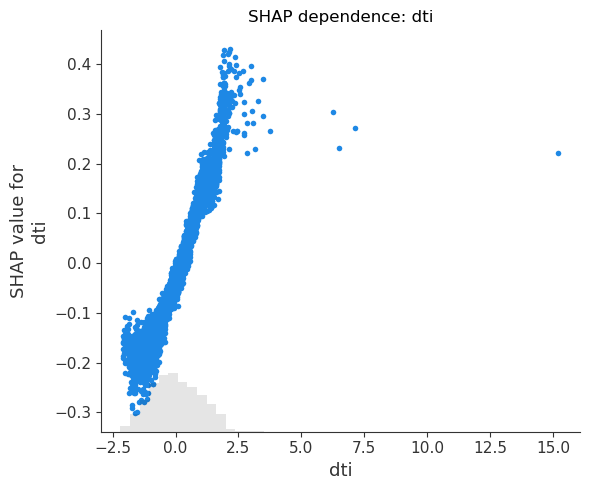

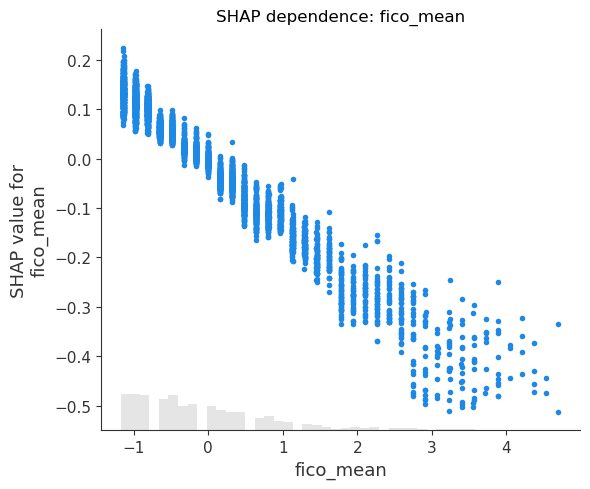

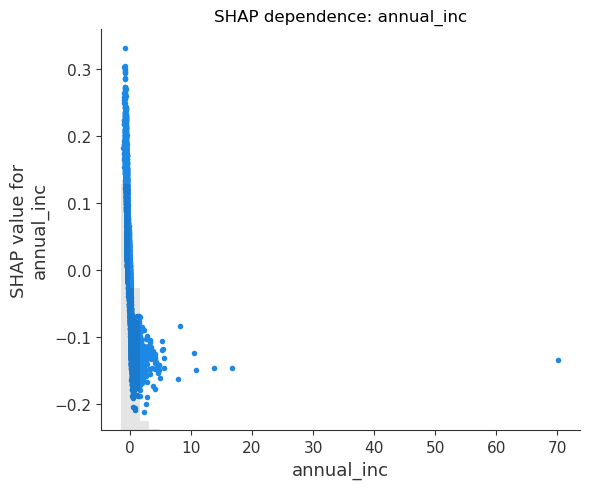

In [9]:
# Dependence plots for the top continuous features: how the SHAP contribution varies with feature value.
CONTINUOUS = [
    'int_rate_clean', 'dti', 'fico_mean', 'term_months', 'annual_inc', 'loan_amnt',
    'revol_util_clean', 'acc_open_past_24mths', 'avg_cur_bal', 'installment',
    'credit_history_years', 'mths_since_last_delinq',
]
dep_feats = [f for f in importance['feature'] if f in CONTINUOUS][:N_DEPENDENCE]
print('Dependence plots for:', dep_feats)
for feat in dep_feats:
    shap.plots.scatter(expl_val[:, feat], show=False)
    plt.title(f'SHAP dependence: {feat}')
    plt.tight_layout(); plt.savefig(PLOT_DIR / f'shap_dependence_{feat}.png', dpi=150, bbox_inches='tight'); plt.show(); plt.close()

## Stability check: validation vs test

Confirms the top risk drivers are consistent on the held-out future period, not an artifact of the tuning period.

In [10]:
test_importance = (
    pd.DataFrame({'feature': X_test_s.columns, 'mean_abs_shap_test': np.abs(expl_test.values).mean(axis=0)})
    .sort_values('mean_abs_shap_test', ascending=False).reset_index(drop=True)
)
val_rank = importance[['feature', 'mean_abs_shap']].copy()
val_rank['rank_validation'] = val_rank['mean_abs_shap'].rank(ascending=False).astype(int)
test_rank = test_importance.copy()
test_rank['rank_test'] = test_rank['mean_abs_shap_test'].rank(ascending=False).astype(int)
stability = (
    val_rank.merge(test_rank, on='feature')
    .assign(rank_shift=lambda d: (d['rank_validation'] - d['rank_test']).abs())
    .sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
)
stability.to_csv(TABLE_DIR / 'shap_validation_vs_test_stability.csv', index=False)
print('Rank correlation (Spearman) val vs test:',
      round(stability['rank_validation'].corr(stability['rank_test'], method='spearman'), 4))
stability.head(TOP_K)

Rank correlation (Spearman) val vs test: 0.9987


,feature,mean_abs_shap,rank_validation,mean_abs_shap_test,rank_test,rank_shift
0,int_rate_clean,0.392764,1,0.429960,1,0
1,term_months,0.245731,2,0.256119,2,0
2,acc_open_past_24mths,0.164227,3,0.160480,3,0
3,dti,0.115910,4,0.124064,4,0
4,fico_mean,0.097573,5,0.112793,5,0
5,annual_inc,0.082181,6,0.086607,6,0
6,loan_amnt,0.078875,7,0.081848,7,0
7,avg_cur_bal,0.065407,8,0.072758,8,0
8,mort_acc,0.046492,9,0.046402,11,2
9,total_acc,0.043176,10,0.044615,12,2


## Local interpretation (borrower-level examples)

In [11]:
proba = pd.Series(model.predict_proba(X_val_s)[:, 1], index=X_val_s.index, name='predicted_default_prob')

def explain_rows(indices, tag):
    rows = []
    for rank, idx in enumerate(indices, start=1):
        pos = X_val_s.index.get_loc(idx)
        row_shap = pd.Series(shap_val[pos], index=X_val_s.columns)
        for direction, series in [('increases_risk', row_shap.sort_values(ascending=False).head(TOP_K)),
                                  ('lowers_risk', row_shap.sort_values().head(TOP_K))]:
            for feature, val in series.items():
                rows.append({'group': tag, 'example_rank': rank, 'row_index': idx,
                             'predicted_default_prob': round(float(proba[idx]), 4),
                             'observed_target_bad': int(y_val_s[idx]),
                             'direction': direction, 'feature': feature,
                             'shap_value': round(float(val), 6),
                             'feature_value': X_val_s.loc[idx, feature]})
    return rows

high_risk_idx = proba.sort_values(ascending=False).head(N_LOCAL_EXAMPLES).index
low_risk_idx = proba.sort_values(ascending=True).head(N_LOCAL_EXAMPLES).index
local_df = pd.DataFrame(explain_rows(high_risk_idx, 'high_risk') + explain_rows(low_risk_idx, 'low_risk'))
local_df.to_csv(TABLE_DIR / 'shap_local_examples.csv', index=False)
local_df[local_df['group'] == 'high_risk'].head(2 * TOP_K)

,group,example_rank,row_index,predicted_default_prob,observed_target_bad,direction,feature,shap_value,feature_value
0,high_risk,1,443554,0.722,1,increases_risk,int_rate_clean,0.683912,2.672293
1,high_risk,1,443554,0.722,1,increases_risk,acc_open_past_24mths,0.418310,2.833535
2,high_risk,1,443554,0.722,1,increases_risk,term_months,0.404577,1.760525
3,high_risk,1,443554,0.722,1,increases_risk,dti,0.194002,1.296258
4,high_risk,1,443554,0.722,1,increases_risk,fico_mean,0.149068,-1.138530
5,high_risk,1,443554,0.722,1,increases_risk,avg_cur_bal,0.146210,-0.652616
6,high_risk,1,443554,0.722,1,increases_risk,loan_amnt,0.105593,0.774083
7,high_risk,1,443554,0.722,1,increases_risk,home_ownership_RENT,0.069941,1.000000
8,high_risk,1,443554,0.722,1,increases_risk,inq_last_6mths,0.045550,2.404501
9,high_risk,1,443554,0.722,1,increases_risk,total_bc_limit,0.042172,-0.568253


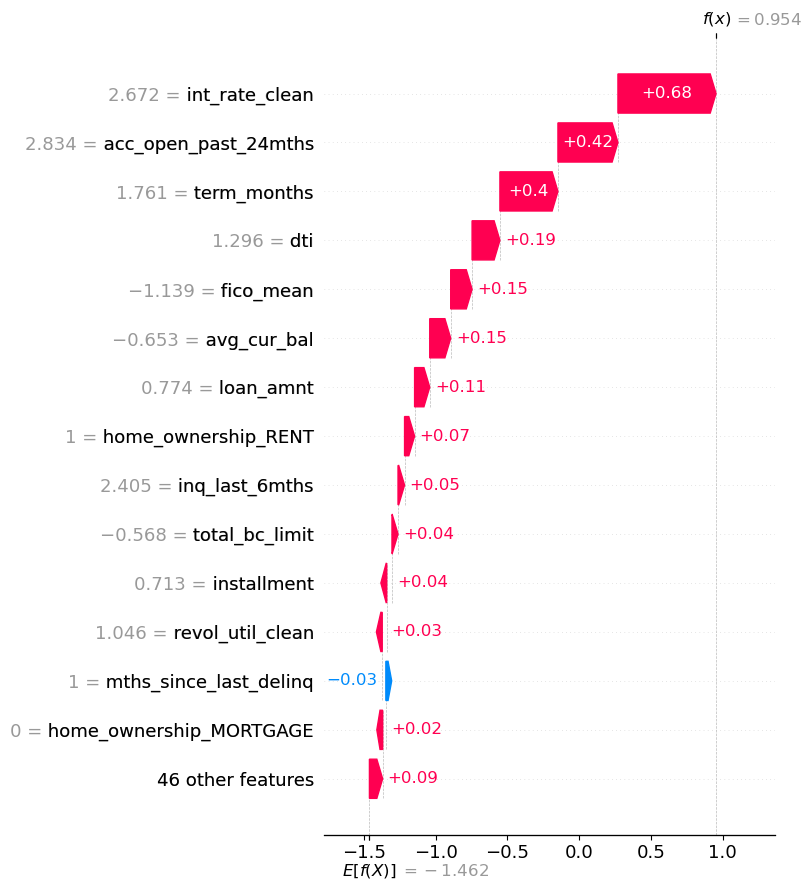

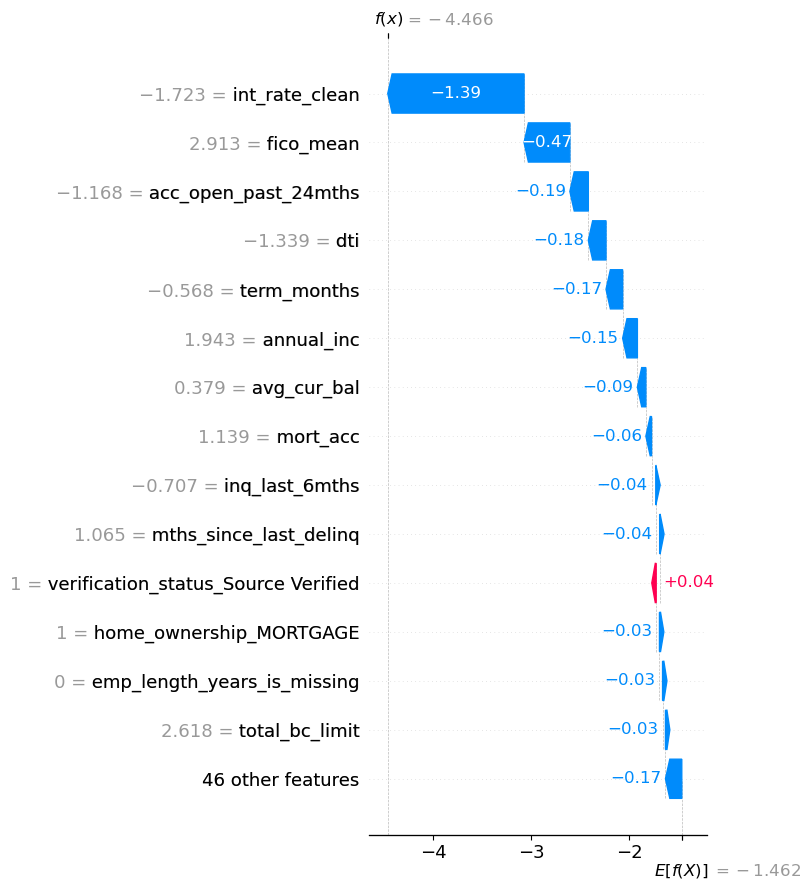

In [12]:
# Waterfall plots: highest-risk and (contrast) lowest-risk accepted loan.
for label, idx in [('top_risk', high_risk_idx[0]), ('low_risk', low_risk_idx[0])]:
    pos = X_val_s.index.get_loc(idx)
    plt.figure()
    shap.plots.waterfall(expl_val[pos], max_display=TOP_K, show=False)
    plt.tight_layout(); plt.savefig(PLOT_DIR / f'shap_waterfall_{label}_example.png', dpi=150, bbox_inches='tight'); plt.show(); plt.close()

## Draft reason-code mapping

Maps technical feature families to draft human-readable reason categories (from `README.md`), then aggregates SHAP importance to the reason-code family level. Discovery artifact, not an approved adverse-action reason code.

In [13]:
REASON_MAP = [
    ('dti', 'High debt burden relative to income.'),
    ('revol_util_clean', 'High revolving credit utilization.'),
    ('fico_mean', 'Lower credit score range.'),
    ('credit_history_years', 'Shorter credit history.'),
    ('mths_since_last_delinq', 'Recent or missing delinquency history signal.'),
    ('annual_inc', 'Lower reported income relative to requested credit.'),
    ('loan_amnt', 'Larger requested loan amount.'),
    ('installment', 'Larger payment obligation.'),
    ('int_rate_clean', 'Higher priced loan (pricing/risk signal for accepted loans).'),
    ('term_months', 'Longer loan repayment term.'),
    ('acc_open_past_24mths', 'Multiple credit accounts opened in the past 24 months.'),
    ('avg_cur_bal', 'Lower average balance across existing credit accounts.'),
]
DO_NOT_USE_DIRECTLY = ('addr_state', 'zip_code', 'home_ownership')  # proxy / fair-lending review needed

def map_reason(feature: str):
    for family, reason in REASON_MAP:
        if feature == family or feature.startswith(family):
            return family, reason
    return None, None

rows = []
for _, r in importance.iterrows():
    fam, reason = map_reason(r['feature'])
    rows.append({'feature': r['feature'], 'feature_family': fam, 'draft_reason_code': reason,
                 'applicant_facing_review_required': r['feature'].startswith(DO_NOT_USE_DIRECTLY),
                 'mean_abs_shap': r['mean_abs_shap']})
reason_df = pd.DataFrame(rows)
reason_df.to_csv(REASON_DIR / 'draft_reason_code_mapping.csv', index=False)
print('Unmapped high-importance features (candidates for new reason codes):')
display(reason_df[reason_df['draft_reason_code'].isna()].head(TOP_K))
reason_df.head(TOP_K)

Unmapped high-importance features (candidates for new reason codes):


,feature,feature_family,draft_reason_code,applicant_facing_review_required,mean_abs_shap
8,mort_acc,None,None,False,0.046492
9,total_acc,None,None,False,0.043176
11,home_ownership_RENT,None,None,True,0.041030
12,emp_length_years_is_missing,None,None,False,0.040114
13,total_bc_limit,None,None,False,0.030960
14,inq_last_6mths,None,None,False,0.030304
15,revol_bal,None,None,False,0.026601
16,home_ownership_MORTGAGE,None,None,True,0.025960
18,verification_status_Source Verified,None,None,False,0.023624
19,total_il_high_credit_limit,None,None,False,0.020148


,feature,feature_family,draft_reason_code,applicant_facing_review_required,mean_abs_shap
0,int_rate_clean,int_rate_clean,Higher priced loan (pricing/risk signal for ac...,False,0.392764
1,term_months,term_months,Longer loan repayment term.,False,0.245731
2,acc_open_past_24mths,acc_open_past_24mths,Multiple credit accounts opened in the past 24...,False,0.164227
3,dti,dti,High debt burden relative to income.,False,0.115910
4,fico_mean,fico_mean,Lower credit score range.,False,0.097573
5,annual_inc,annual_inc,Lower reported income relative to requested cr...,False,0.082181
6,loan_amnt,loan_amnt,Larger requested loan amount.,False,0.078875
7,avg_cur_bal,avg_cur_bal,Lower average balance across existing credit a...,False,0.065407
8,mort_acc,None,None,False,0.046492
9,total_acc,None,None,False,0.043176


In [14]:
# Aggregate SHAP importance to the reason-code family level (ranks the draft reasons by total contribution).
family = (
    reason_df.dropna(subset=['feature_family'])
    .groupby(['feature_family', 'draft_reason_code'], as_index=False)['mean_abs_shap'].sum()
    .sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
)
family['share_of_mapped_importance'] = (family['mean_abs_shap'] / family['mean_abs_shap'].sum()).round(4)
family.to_csv(TABLE_DIR / 'shap_reason_code_family_importance.csv', index=False)
family

,feature_family,draft_reason_code,mean_abs_shap,share_of_mapped_importance
0,int_rate_clean,Higher priced loan (pricing/risk signal for ac...,0.392764,0.2917
1,term_months,Longer loan repayment term.,0.245731,0.1825
2,acc_open_past_24mths,Multiple credit accounts opened in the past 24...,0.164227,0.1220
3,dti,High debt burden relative to income.,0.115910,0.0861
4,fico_mean,Lower credit score range.,0.097573,0.0725
5,annual_inc,Lower reported income relative to requested cr...,0.082181,0.0610
6,loan_amnt,Larger requested loan amount.,0.078875,0.0586
7,avg_cur_bal,Lower average balance across existing credit a...,0.065407,0.0486
8,installment,Larger payment obligation.,0.042964,0.0319
9,revol_util_clean,High revolving credit utilization.,0.025216,0.0187


## Outputs written

Tables (`shap_outputs/tables/`): `shap_global_mean_abs_importance.csv`, `shap_top_positive_risk_drivers.csv`, `shap_validation_vs_test_stability.csv`, `shap_local_examples.csv`, `shap_reason_code_family_importance.csv`.

Plots (`shap_outputs/plots/`): `shap_summary_beeswarm.png`, `shap_mean_abs_bar.png`, `shap_dependence_*.png`, `shap_waterfall_top_risk_example.png`, `shap_waterfall_low_risk_example.png`.

Reason codes (`reason_codes/`): `draft_reason_code_mapping.csv`.

**Reminder:** these explain model behavior. They are not compliance-approved adverse-action reasons and do not make the model production-ready for lending decisions.